In [1]:
import gymnasium as gym
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import wandb
import pprint
import random

In [2]:
wandb.login()

Failed to detect the name of this notebook, you can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.
wandb: Currently logged in as: me21b145 to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [3]:
sweep_config = {'method': 'random'}

metric = {
    'name': 'reward',
    'goal': 'maximize'   
    }
sweep_config['metric'] = metric

parameters = {
    'learning_rate': {'values': [0.01, 0.05, 0.001]},
    'batch_size': {'values': [64, 128]},
    'episodes': {'values': [2500, 5000, 7500, 10000]},
    'discount_factor':{'value':0.99},
    'epsilon': {'values':[0.1, 0.2, 0.3]},
    'epsilon_decay': {'values':[0.01, 0.005, 0.001]},
    }
sweep_config['parameters'] = parameters

pprint.pprint(sweep_config)
sweep_id = wandb.sweep(sweep_config, project="RL_PA2_Acrobot_MonteCarlo")

{'method': 'random',
 'metric': {'goal': 'maximize', 'name': 'reward'},
 'parameters': {'batch_size': {'values': [64, 128]},
                'discount_factor': {'value': 0.99},
                'episodes': {'values': [2500, 5000, 7500, 10000]},
                'epsilon': {'values': [0.1, 0.2, 0.3]},
                'epsilon_decay': {'values': [0.01, 0.005, 0.001]},
                'learning_rate': {'values': [0.01, 0.05, 0.001]}}}
Create sweep with ID: ggeuv13g
Sweep URL: https://wandb.ai/me21b145/RL_PA2_Acrobot_MonteCarlo/sweeps/ggeuv13g


In [4]:
GAMMA = 0.99
LR = 1e-3
BATCH_SIZE = 64
EPSILON_START = 1.0
EPSILON_END = 0.01
EPSILON_DECAY = 0.995
MEMORY_SIZE = 10000
TARGET_UPDATE_FREQ = 10
NUM_EPISODES = 1000

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [6]:
class PolicyNetwork(nn.Module):
    def __init__(self, state_dim, action_dim):
        super(PolicyNetwork, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(state_dim, 128),
            nn.ReLU(),
            nn.Linear(128, action_dim),
            nn.Softmax(dim=-1)
        )

    def forward(self, x):
        return self.model(x)

In [7]:
class ValueNetwork(nn.Module):
    def __init__(self, state_dim):
        super(ValueNetwork, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(state_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        return self.model(x)

In [8]:
def select_action(policy_net, state):
    state = torch.tensor(state, dtype=torch.float32).unsqueeze(0).to(device)
    probs = policy_net(state)
    dist = torch.distributions.Categorical(probs)
    action = dist.sample()
    return action.item(), dist.log_prob(action), state

In [9]:
def compute_returns(rewards, discount=0.99):
    G = 0
    returns = []
    for r in reversed(rewards):
        G = r + discount * G
        returns.insert(0, G)
    returns = torch.tensor(returns, dtype=torch.float32).to(device)
    return returns

In [10]:
def run_episode(env, policy_net):
    state, _ = env.reset()
    log_probs = []
    rewards = []
    states = []

    for _ in range(1000):
        action, log_prob, state_tensor = select_action(policy_net, state)
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        log_probs.append(log_prob)
        rewards.append(reward)
        states.append(state_tensor)
        state = next_state
        if done:
            break
    return log_probs, rewards, states

In [11]:
def train_reinforce(env, lr, discount, episodes, device, type=1, is_wandb=False):
    state_dim = env.observation_space.shape[0]
    action_dim = env.action_space.n

    policy_net = PolicyNetwork(state_dim, action_dim).to(device)
    policy_optimizer = optim.Adam(policy_net.parameters(), lr)

    if type == 2:
        value_net = ValueNetwork(state_dim).to(device)
        value_optimizer = optim.Adam(value_net.parameters(), lr)

    all_rewards = []
    return_per_episode = []
    returns = []

    for episode in range(episodes):
        log_probs, rewards, states = run_episode(env, policy_net)
        returns = compute_returns(rewards, discount)

        loss = 0
        if type == 1:
            returns = (returns - returns.mean()) / (returns.std() + 1e-9)
            for log_prob, G in zip(log_probs, returns):
                loss += -log_prob * G

        else:
            state_batch = torch.cat(states)
            values = value_net(state_batch).squeeze()
            advantages = returns - values.detach()
            for log_prob, adv in zip(log_probs, advantages):
                loss += -log_prob * adv

            value_loss = nn.MSELoss()(values, returns)
            value_optimizer.zero_grad()
            value_loss.backward()
            value_optimizer.step()

        policy_optimizer.zero_grad()
        loss.backward()
        policy_optimizer.step()

        total_reward = sum(rewards)
        all_rewards.append(total_reward)

        if episode == 0:
            return_per_episode.append(total_reward)
        else:
            return_per_episode.append(all_rewards[-1]*discount + total_reward)
        
        if is_wandb:
            wandb.log({"episode": episode, "return": total_reward})

        if episode % 10 == 0:
            print(f"Episode {episode}, Return: {total_reward:.2f}")

    env.close()
    return all_rewards, return_per_episode, returns

In [12]:
def MonteCarlo():
    env = gym.make("Acrobot-v1")
    config = None
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    with wandb.init(config=config):
        lr = wandb.config.learning_rate
        discount = wandb.config.discount_factor
        episodes = wandb.config.episodes
        rewards_no_baseline, returns_no_baseline = train_reinforce(env, lr, discount, episodes, device, type=1, is_wandb=True)
        rewards_with_baseline, returns_with_baseline = train_reinforce(env, lr, discount, episodes, device, type=2, is_wandb=True)

        plt.figure(figsize=(12, 5))
        plt.plot(rewards_no_baseline, 'r', label="Reward without baseline")
        plt.plot(rewards_with_baseline, 'g', label="Reward with baseline")
        plt.xlabel("Episodes")
        plt.ylabel("Rewards")
        plt.title("Rewards per episode (with and without baseline)")
        plt.legend()
        plt.tight_layout()
        
        wandb.log({'Learning Rate': wandb.config.learning_rate, 'Episodes': wandb.config.episodes, 'Rewards per episode': wandb.Image(plt)})
        plt.close()

        env.close()

In [14]:
wandb.agent(sweep_id, MonteCarlo, count=2)

wandb: Agent Starting Run: sxdnqua9 with config:
wandb: 	batch_size: 128
wandb: 	discount_factor: 0.99
wandb: 	episodes: 2500
wandb: 	epsilon: 0.3
wandb: 	epsilon_decay: 0.01
wandb: 	learning_rate: 0.01
Failed to detect the name of this notebook, you can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.


Episode 0, Return: -500.00
Episode 10, Return: -333.00
Episode 20, Return: -208.00
Episode 30, Return: -166.00
Episode 40, Return: -163.00
Episode 50, Return: -358.00
Episode 60, Return: -274.00
Episode 70, Return: -169.00
Episode 80, Return: -316.00
Episode 90, Return: -144.00
Episode 100, Return: -239.00
Episode 110, Return: -184.00
Episode 120, Return: -225.00
Episode 130, Return: -206.00
Episode 140, Return: -159.00
Episode 150, Return: -266.00
Episode 160, Return: -156.00
Episode 170, Return: -161.00
Episode 180, Return: -382.00
Episode 190, Return: -500.00
Episode 200, Return: -500.00
Episode 210, Return: -500.00
Episode 220, Return: -500.00
Episode 230, Return: -500.00
Episode 240, Return: -500.00
Episode 250, Return: -500.00
Episode 260, Return: -500.00
Episode 270, Return: -500.00
Episode 280, Return: -500.00
Episode 290, Return: -500.00
Episode 300, Return: -500.00
Episode 310, Return: -500.00
Episode 320, Return: -500.00
Episode 330, Return: -500.00
Episode 340, Return: -500

Episodes,▁
Learning Rate,▁
episode,▁▁▁▂▂▄▅▅▅▅▇▇▇▇▇▇██▂▂▂▂▂▃▃▄▄▄▄▄▄▅▅▅▅▅▆▆▆▇
return,▆▆▅▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▇███▇▇████▇█▄██████
Episodes,2500
Learning Rate,0.01
episode,2499
return,-72


wandb: Agent Starting Run: pcnrf26v with config:
wandb: 	batch_size: 64
wandb: 	discount_factor: 0.99
wandb: 	episodes: 10000
wandb: 	epsilon: 0.1
wandb: 	epsilon_decay: 0.001
wandb: 	learning_rate: 0.01
Failed to detect the name of this notebook, you can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.


Episode 0, Return: -313.00
Episode 10, Return: -235.00
Episode 20, Return: -106.00
Episode 30, Return: -77.00
Episode 40, Return: -95.00
Episode 50, Return: -93.00
Episode 60, Return: -75.00
Episode 70, Return: -74.00
Episode 80, Return: -133.00
Episode 90, Return: -98.00
Episode 100, Return: -64.00
Episode 110, Return: -80.00
Episode 120, Return: -119.00
Episode 130, Return: -76.00
Episode 140, Return: -72.00
Episode 150, Return: -91.00
Episode 160, Return: -75.00
Episode 170, Return: -71.00
Episode 180, Return: -72.00
Episode 190, Return: -71.00
Episode 200, Return: -114.00
Episode 210, Return: -97.00
Episode 220, Return: -77.00
Episode 230, Return: -174.00
Episode 240, Return: -83.00
Episode 250, Return: -187.00
Episode 260, Return: -133.00
Episode 270, Return: -98.00
Episode 280, Return: -100.00
Episode 290, Return: -83.00
Episode 300, Return: -75.00
Episode 310, Return: -75.00
Episode 320, Return: -76.00
Episode 330, Return: -68.00
Episode 340, Return: -84.00
Episode 350, Return: 

Episodes,▁
Learning Rate,▁
episode,▂▂▂▂▂▃▃▃▄▄▄▄▅▅▅▆▆▇▇▇████▁▂▂▃▃▄▅▅▅▅▆▆▆▇▇█
return,██▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
Episodes,10000
Learning Rate,0.01
episode,9999
return,-500


In [14]:
def mean_and_variance(x):
    sum_mean = 0
    mean = []
    variance = []
    for i in range(len(x)):
        sum_mean += x[i]
        mean.append(sum_mean/(i+1))
        sum_variance = 0
        for j in range(0,i+1):
            sum_variance += (x[j] - mean[i])**2
        variance.append(sum_variance/(i+1))

    return mean, variance

Episode 0, Return: -500.00
Episode 10, Return: -500.00
Episode 20, Return: -500.00
Episode 30, Return: -500.00
Episode 40, Return: -500.00
Episode 50, Return: -393.00
Episode 60, Return: -347.00
Episode 70, Return: -306.00
Episode 80, Return: -379.00
Episode 90, Return: -320.00
Episode 100, Return: -235.00
Episode 110, Return: -162.00
Episode 120, Return: -198.00
Episode 130, Return: -290.00
Episode 140, Return: -244.00
Episode 150, Return: -214.00
Episode 160, Return: -184.00
Episode 170, Return: -225.00
Episode 180, Return: -145.00
Episode 190, Return: -329.00
Episode 200, Return: -245.00
Episode 210, Return: -264.00
Episode 220, Return: -282.00
Episode 230, Return: -262.00
Episode 240, Return: -215.00
Episode 250, Return: -225.00
Episode 260, Return: -125.00
Episode 270, Return: -197.00
Episode 280, Return: -119.00
Episode 290, Return: -117.00
Episode 300, Return: -129.00
Episode 310, Return: -171.00
Episode 320, Return: -158.00
Episode 330, Return: -120.00
Episode 340, Return: -104

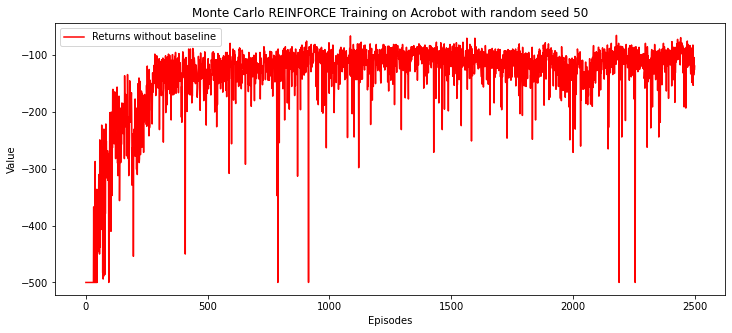

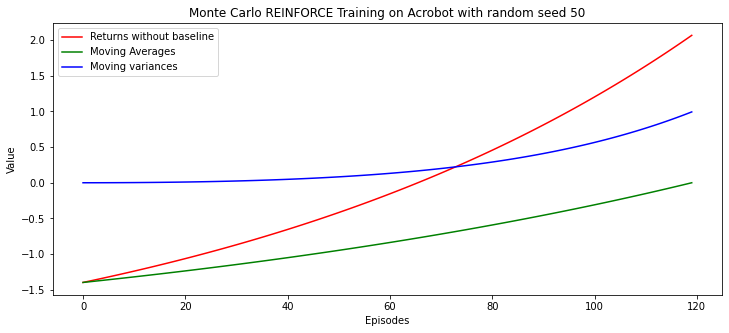

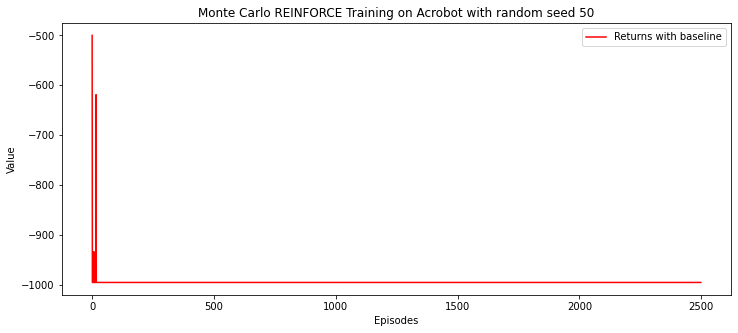

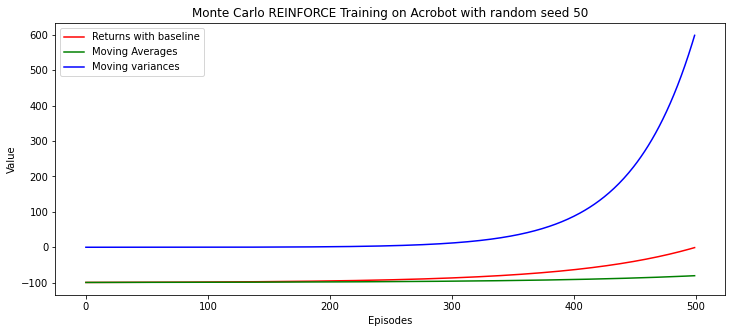

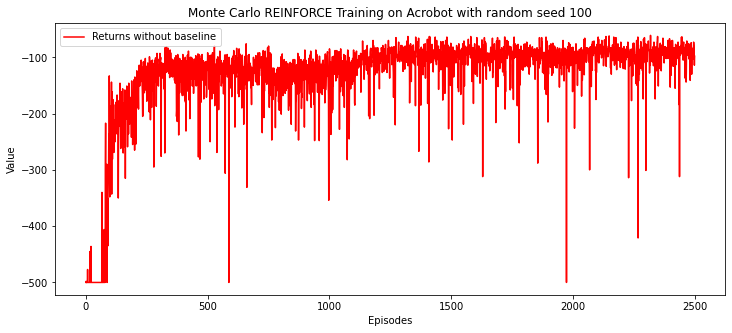

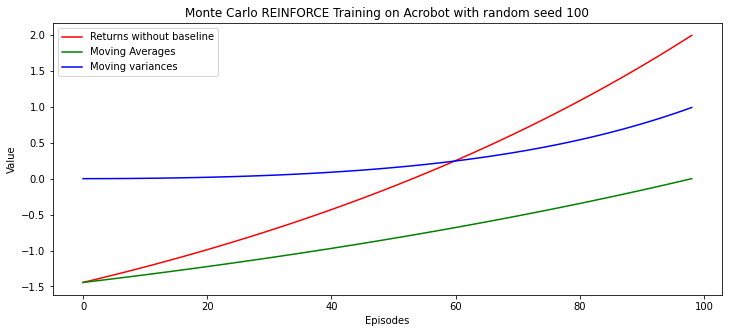

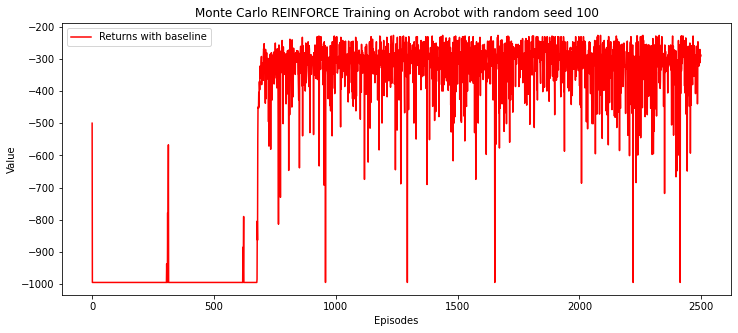

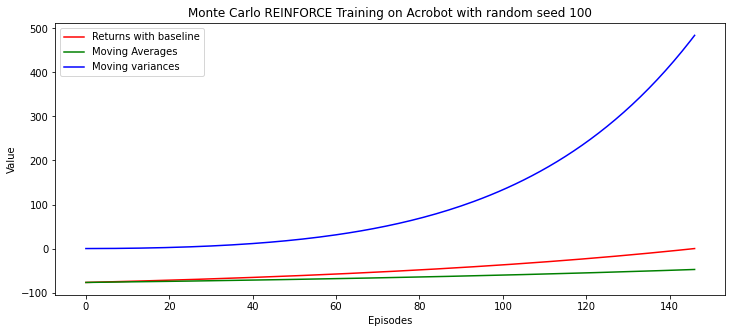

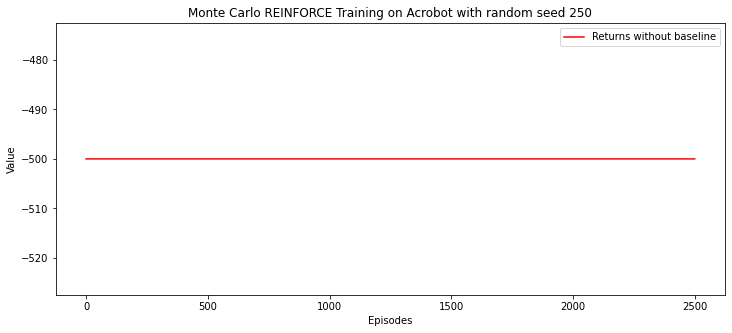

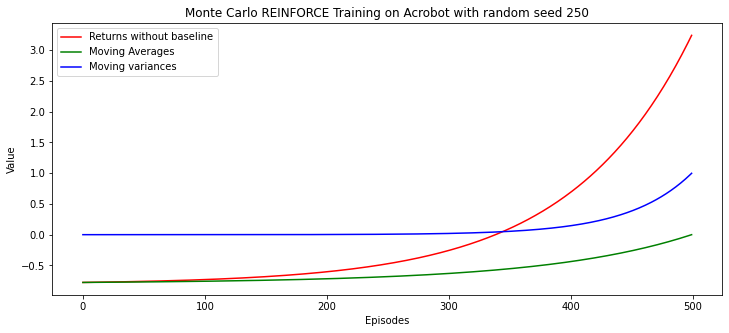

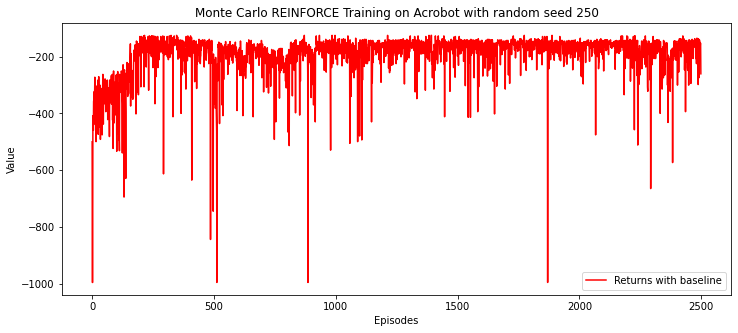

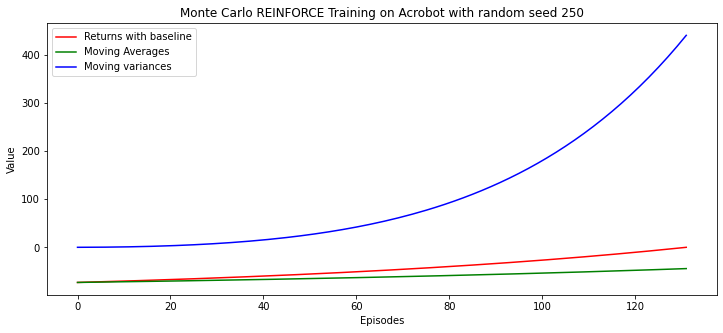

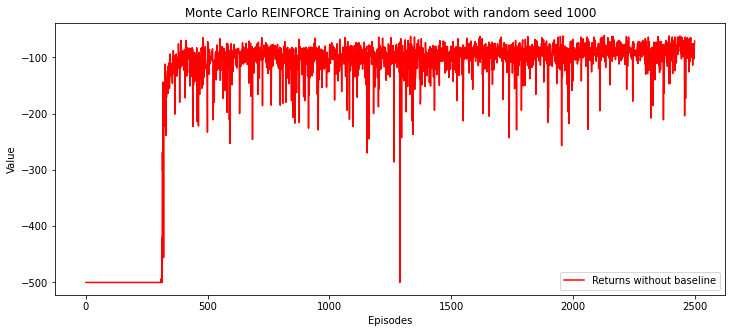

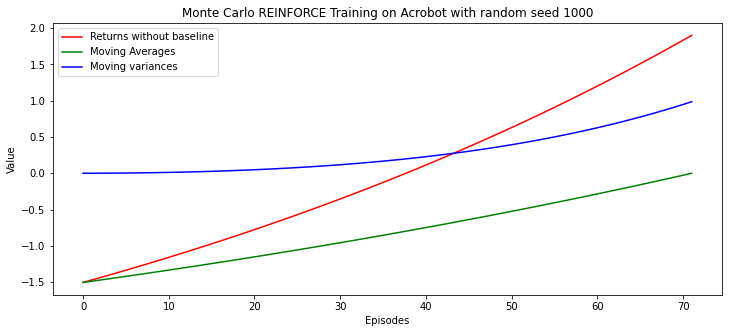

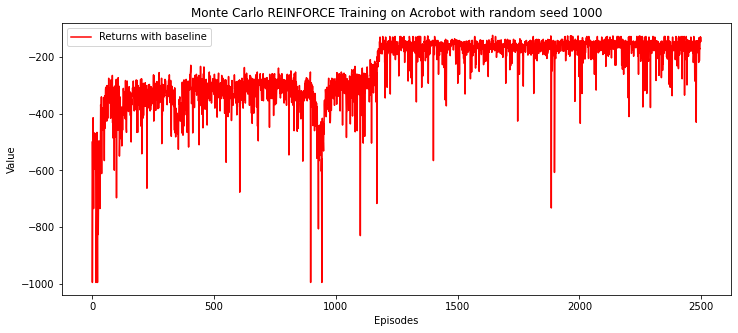

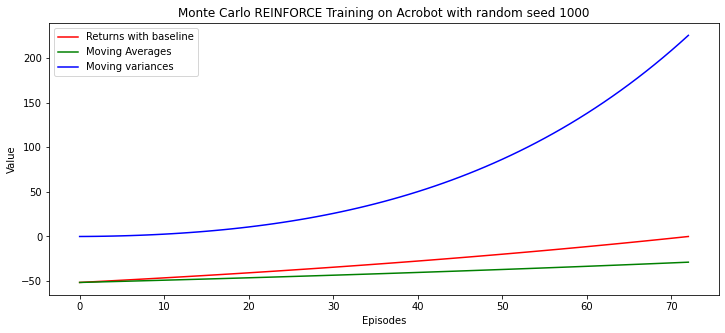

In [ ]:
seeds = [10, 50, 100, 250, 1000]

env = gym.make("Acrobot-v1")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

for seed in seeds:
    np.random.seed(seed)
    random.seed(seed)

    lr = 0.001
    episodes = 2500
    discount = 0.99
    rewards_no_baseline, returns_no_baseline, returns1 = train_reinforce(env, lr, discount, episodes, device, type=1, is_wandb=False)

    mean_returns_type1, var_returns_type1 = mean_and_variance(returns1)

    lr = 0.01
    episodes = 2500
    discount = 0.99
    rewards_with_baseline, returns_with_baseline, returns2 = train_reinforce(env, lr, discount, episodes, device, type=2, is_wandb=False)

    mean_returns_type2, var_returns_type2 = mean_and_variance(returns2)

    plt.figure(figsize=(12, 5))
    plt.plot(rewards_no_baseline, 'r', label="Returns without baseline")
    plt.xlabel("Episodes")
    plt.ylabel("Value")
    plt.title(f"Monte Carlo REINFORCE Training on Acrobot with random seed {seed}")
    plt.legend()

    plt.figure(figsize=(12, 5))
    plt.plot(returns1, 'r', label="Returns without baseline")
    plt.plot(mean_returns_type1, 'g', label="Moving Averages")
    plt.plot(var_returns_type1, 'b', label="Moving variances")
    plt.xlabel("Episodes")
    plt.ylabel("Value")
    plt.title(f"Monte Carlo REINFORCE Training on Acrobot with random seed {seed}")
    plt.legend()

    plt.figure(figsize=(12, 5))
    plt.plot(returns_with_baseline, 'r', label="Returns with baseline")
    plt.xlabel("Episodes")
    plt.ylabel("Value")
    plt.title(f"Monte Carlo REINFORCE Training on Acrobot with random seed {seed}")
    plt.legend()

    plt.figure(figsize=(12, 5))
    plt.plot(returns2, 'r', label="Returns with baseline")
    plt.plot(mean_returns_type2, 'g', label="Moving Averages")
    plt.plot(var_returns_type2, 'b', label="Moving variances")
    plt.xlabel("Episodes")
    plt.ylabel("Value")
    plt.title(f"Monte Carlo REINFORCE Training on Acrobot with random seed {seed}")
    plt.legend()
    
    print(f"Seed {seed} Done")